In [23]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [24]:
path = 'gold_data_scaled_stationary.csv'
df = pd.read_csv(path)
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY,Close
0,2019-01-02,0.0,0.0,0.0,0.015677,-0.019422,0.004996
1,2019-01-03,0.0,0.0,0.0,0.015677,-0.019422,0.004996
2,2019-01-04,0.0,0.0,0.0,0.004106,0.003716,-0.004209
3,2019-01-07,0.0,0.0,0.0,0.021650,0.005573,0.001897
4,2019-01-08,0.0,0.0,0.0,-0.008959,-0.000844,-0.001665


In [25]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

In [26]:
feature_cols = ['Crude_Oil', 'Inflation', 'Interest_Rate', 'USD_EUR', 'USD_JPY']
target_col = ['Close']

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values
X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

In [27]:
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [28]:
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(128, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))  
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

In [29]:
def build_bilstm_model(input_shape):
    model = Sequential()
    model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

In [30]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/100


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 - 2s - 54ms/step - loss: 6.0001e-05 - val_loss: 4.1908e-05
Epoch 2/100
39/39 - 0s - 7ms/step - loss: 5.4416e-05 - val_loss: 4.0719e-05
Epoch 3/100
39/39 - 0s - 6ms/step - loss: 5.3460e-05 - val_loss: 3.7194e-05
Epoch 4/100
39/39 - 0s - 8ms/step - loss: 5.4477e-05 - val_loss: 4.1720e-05
Epoch 5/100
39/39 - 0s - 6ms/step - loss: 5.3238e-05 - val_loss: 3.6739e-05
Epoch 6/100
39/39 - 0s - 6ms/step - loss: 5.1388e-05 - val_loss: 3.8889e-05
Epoch 7/100
39/39 - 0s - 6ms/step - loss: 5.2541e-05 - val_loss: 3.6382e-05
Epoch 8/100
39/39 - 0s - 6ms/step - loss: 5.0690e-05 - val_loss: 3.7028e-05
Epoch 9/100
39/39 - 0s - 6ms/step - loss: 5.1089e-05 - val_loss: 3.7244e-05
Epoch 10/100
39/39 - 0s - 6ms/step - loss: 5.1269e-05 - val_loss: 3.7559e-05
Epoch 11/100
39/39 - 0s - 6ms/step - loss: 5.0643e-05 - val_loss: 4.0020e-05
Epoch 12/100
39/39 - 0s - 6ms/step - loss: 5.1209e-05 - val_loss: 3.7326e-05
Epoch 13/100
39/39 - 0s - 6ms/step - loss: 5.1325e-05 - val_loss: 3.6574e-05
Epoch 14/100
39/39 

In [31]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

bilstm_model = build_bilstm_model((X_train.shape[1], X_train.shape[2]))
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/100


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 - 0s - 7ms/step - loss: 5.1073e-05 - val_loss: 4.0006e-05
Epoch 2/100
39/39 - 0s - 6ms/step - loss: 5.2625e-05 - val_loss: 3.6900e-05
Epoch 3/100
39/39 - 0s - 8ms/step - loss: 5.1092e-05 - val_loss: 4.3119e-05
Epoch 4/100
39/39 - 0s - 6ms/step - loss: 5.1429e-05 - val_loss: 3.9995e-05
Epoch 5/100
39/39 - 0s - 6ms/step - loss: 5.1175e-05 - val_loss: 3.6589e-05
Epoch 6/100
39/39 - 0s - 6ms/step - loss: 5.1694e-05 - val_loss: 4.3944e-05
Epoch 7/100
39/39 - 0s - 6ms/step - loss: 5.0502e-05 - val_loss: 3.7704e-05
Epoch 8/100
39/39 - 0s - 6ms/step - loss: 5.4155e-05 - val_loss: 3.6664e-05
Epoch 9/100
39/39 - 0s - 6ms/step - loss: 5.0816e-05 - val_loss: 3.7359e-05
Epoch 10/100
39/39 - 0s - 6ms/step - loss: 5.4573e-05 - val_loss: 4.0623e-05
Epoch 11/100
39/39 - 0s - 7ms/step - loss: 5.3332e-05 - val_loss: 3.6641e-05
Epoch 12/100
39/39 - 0s - 6ms/step - loss: 5.4191e-05 - val_loss: 6.2721e-05
Epoch 13/100
39/39 - 0s - 7ms/step - loss: 5.7998e-05 - val_loss: 3.8735e-05
Epoch 14/100
39/39 -

In [32]:
y_pred = model.predict(X_test)
y_pred_bilstm = bilstm_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

bi_mae = mean_absolute_error(y_test, y_pred_bilstm)
bi_rmse = np.sqrt(mean_squared_error(y_test, y_pred_bilstm))
bi_r2 = r2_score(y_test, y_pred_bilstm)

results = pd.DataFrame({
    'MAE': [mae, bi_mae],
    'RMSE': [rmse, bi_rmse],
    'R2': [r2, bi_r2]
})

print(results)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
        MAE      RMSE        R2
0  0.010391  0.014429  0.006002
1  0.010558  0.014602 -0.017972


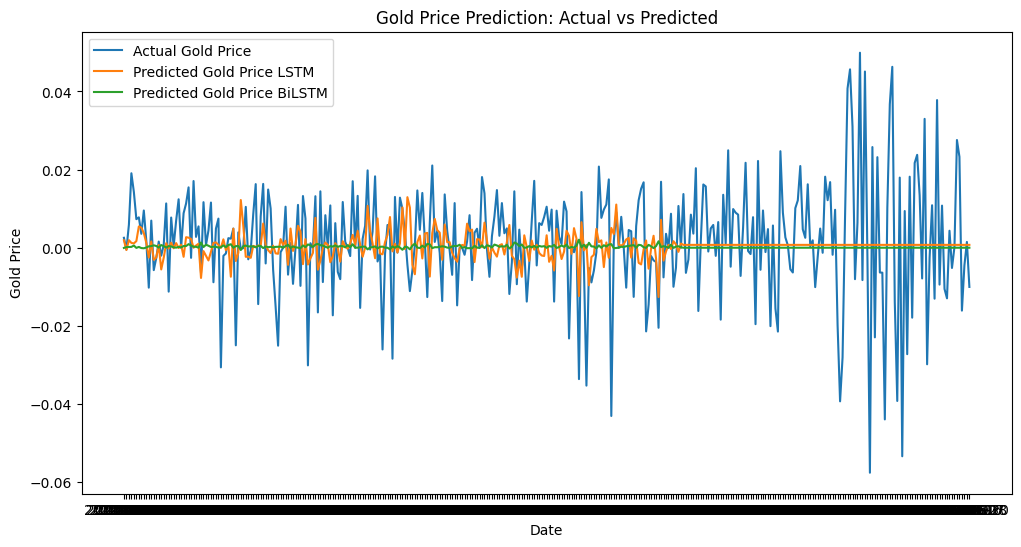

In [33]:
plt.figure(figsize=(12,6))
plt.plot(test_df['Date'], y_test, label='Actual Gold Price')
plt.plot(test_df['Date'], y_pred, label='Predicted Gold Price LSTM')
plt.plot(test_df['Date'], y_pred_bilstm, label='Predicted Gold Price BiLSTM')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.title('Gold Price Prediction: Actual vs Predicted')
plt.legend()
plt.show()

In [34]:
import joblib 

target_scaler = joblib.load('scalers/target_scaler.pkl')
inverted_preds = target_scaler.inverse_transform(y_pred)
print(inverted_preds)

[[1273.4263]
 [1268.0304]
 [1273.4791]
 [1271.968 ]
 [1271.6797]
 [1272.961 ]
 [1281.0953]
 [1280.4279]
 [1277.4146]
 [1272.0314]
 [1263.8694]
 [1272.7784]
 [1262.606 ]
 [1263.8518]
 [1270.7739]
 [1257.2859]
 [1263.7389]
 [1271.8142]
 [1268.8229]
 [1272.063 ]
 [1268.9956]
 [1271.8756]
 [1269.1351]
 [1270.9656]
 [1264.2861]
 [1275.1174]
 [1274.8759]
 [1274.1381]
 [1269.3048]
 [1270.5127]
 [1271.504 ]
 [1252.5728]
 [1267.426 ]
 [1264.8718]
 [1262.2609]
 [1267.1174]
 [1271.9441]
 [1272.2306]
 [1270.8828]
 [1269.2477]
 [1273.9469]
 [1267.9607]
 [1270.7959]
 [1253.2369]
 [1279.8429]
 [1261.924 ]
 [1266.4746]
 [1295.691 ]
 [1281.4697]
 [1264.2646]
 [1264.3607]
 [1263.6956]
 [1270.3429]
 [1269.791 ]
 [1270.508 ]
 [1270.3472]
 [1282.6804]
 [1270.4779]
 [1267.9867]
 [1266.3345]
 [1270.4261]
 [1266.1914]
 [1265.9519]
 [1274.0562]
 [1270.874 ]
 [1273.1486]
 [1259.8467]
 [1279.9268]
 [1267.5167]
 [1271.0719]
 [1281.4398]
 [1278.276 ]
 [1260.2072]
 [1274.045 ]
 [1259.9963]
 [1263.419 ]
 [1266.4261]

In [35]:
joblib.dump(model, 'models/lstm.pkl')

['models/lstm.pkl']

In [36]:
joblib.dump(bilstm_model, 'models/bilstm.pkl')

['models/bilstm.pkl']

In [37]:
joblib.dump(early_stop, 'models/early_stop.pkl')

['models/early_stop.pkl']